In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Примеры графиков на основе базы данных в Python

1) Создаем объект графика и задаем (если нужно) его размеры
plt.figure(figsize = (length,heigth))

2) Создается основная визуализация

Любой график в plt или sns строится командой plt.<тип графика>

Например: столбчатая диаграмма plt.bar или sns.barplot

Гистограмма plt.hist или sns.histplot

и т.п.

3) Создаем заголовок plt.title("Заголовок")

4) Подписываем оси X и Y plt.xlabel(), plt.ylabel()

5) Выводим график на экран plt.show()

## Загружаем данные

In [3]:
data = pd.read_csv(r"C:\Courses\Innopolis\2026\ИИ Инженер\Python Data\result_data.csv", index_col = 0)
data.head()

,rental_id,rental_date,return_date,fact_rental_duration,flag_returned,inventory_id,customer_id,staff_id,store_id_x,email,...,customer_name,film_id,store_id_y,normative_rental_duration,film_name,rental_rate,payment_id,amount,payment_date,rental_overdue
16047,1,2005-05-24 22:53:30,2005-05-26 22:04:30,1 days 23:11:00,1,367,130,1,1,charlotte.hunter@sakilacustomer.org,...,Charlotte Hunter,80,1,7 days,Blanket Beverly,2.99,NaN,NaN,NaN,-6 days +23:11:00
0,2,2005-05-24 22:54:33,2005-05-28 19:40:33,3 days 20:46:00,1,1525,459,1,1,tommy.collazo@sakilacustomer.org,...,Tommy Collazo,333,2,7 days,Freaky Pocus,2.99,NaN,NaN,NaN,-4 days +20:46:00
1,3,2005-05-24 23:03:39,2005-06-01 22:12:39,7 days 23:09:00,1,1711,408,1,1,manuel.murrell@sakilacustomer.org,...,Manuel Murrell,373,2,7 days,Graduate Lord,2.99,NaN,NaN,NaN,0 days 23:09:00
2,4,2005-05-24 23:04:41,2005-06-03 01:43:41,9 days 02:39:00,1,2452,333,2,2,andrew.purdy@sakilacustomer.org,...,Andrew Purdy,535,1,6 days,Love Suicides,0.99,NaN,NaN,NaN,3 days 02:39:00
3,5,2005-05-24 23:05:21,2005-06-02 04:33:21,8 days 05:28:00,1,2079,222,1,2,delores.hansen@sakilacustomer.org,...,Delores Hansen,450,2,5 days,Idols Snatchers,2.99,NaN,NaN,NaN,3 days 05:28:00


## Рисуем столбчатую диаграмму

In [8]:
top10_rented = (
    data
    .groupby("film_name")
    .agg(rental_cnt = ("rental_id", "count"))
    .reset_index()
    .sort_values(by = ["rental_cnt", "film_name"], ascending = [False, True])
    .head(10)
)

top10_rented

,film_name,rental_cnt
96,Bucket Brotherhood,34
705,Rocketeer Mother,33
312,Forward Temple,32
361,Grit Clockwork,32
465,Juggler Hardly,32
697,Ridgemont Submarine,32
733,Scalawag Duck,32
29,Apache Divine,31
348,Goodfellas Salute,31
395,Hobbit Alien,31


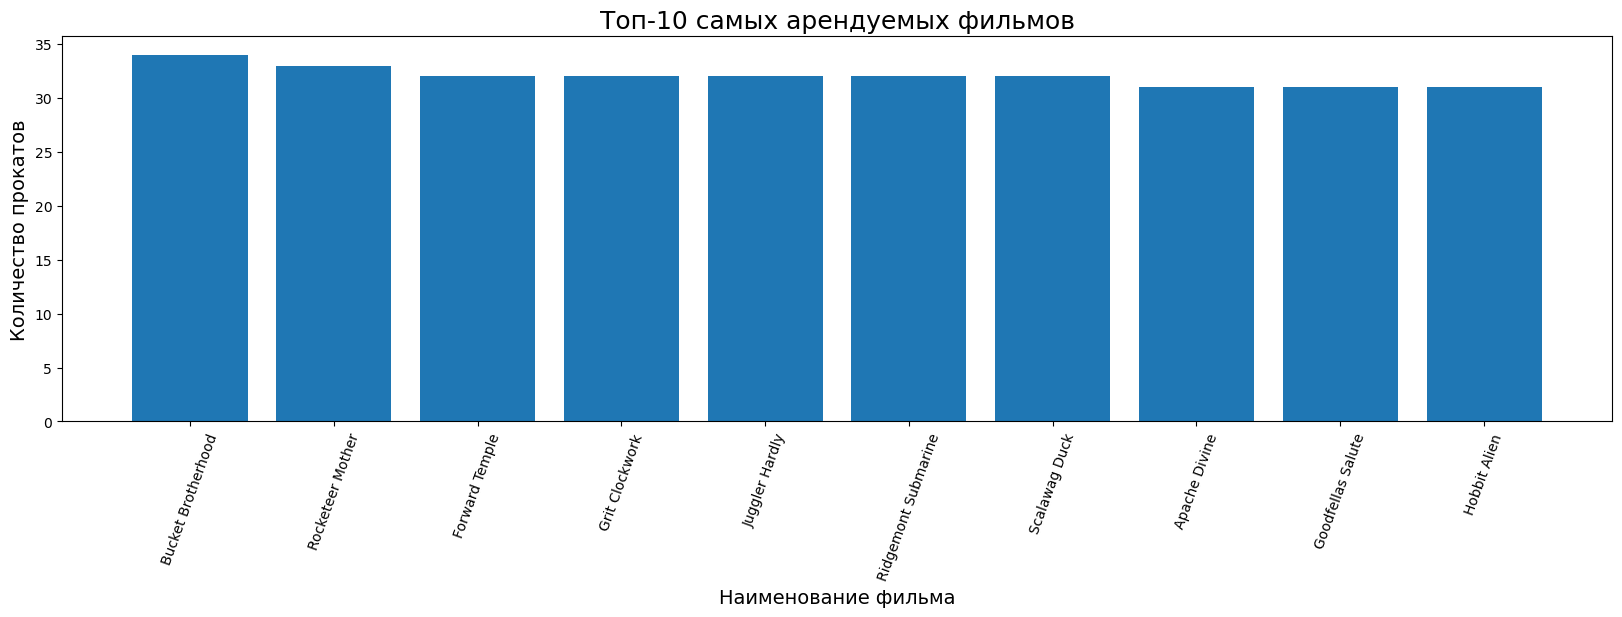

In [9]:
plt.figure(figsize = (20,5))
plt.bar(x = top10_rented["film_name"], height = top10_rented["rental_cnt"])
plt.title("Топ-10 самых арендуемых фильмов", fontsize = 18)
plt.xlabel("Наименование фильма", fontsize = 14)
plt.ylabel("Количество прокатов", fontsize = 14)
plt.xticks(rotation = 70) #Вращение подписей по оси х
plt.show()

## Рисуем линейную диаграмму с количеством прокатов по месяцам

In [14]:
rental_dynamics = (
    data
    .assign(rental_month = lambda x: pd.to_datetime(x["rental_date"]).dt.to_period("M").dt.to_timestamp())
    .groupby("rental_month")
    .agg(rental_cnt = ("rental_id","nunique"))
    .loc["2005", :]
    .reset_index()
)

rental_dynamics

,rental_month,rental_cnt
0,2005-05-01,1156
1,2005-06-01,2311
2,2005-07-01,6709
3,2005-08-01,5686


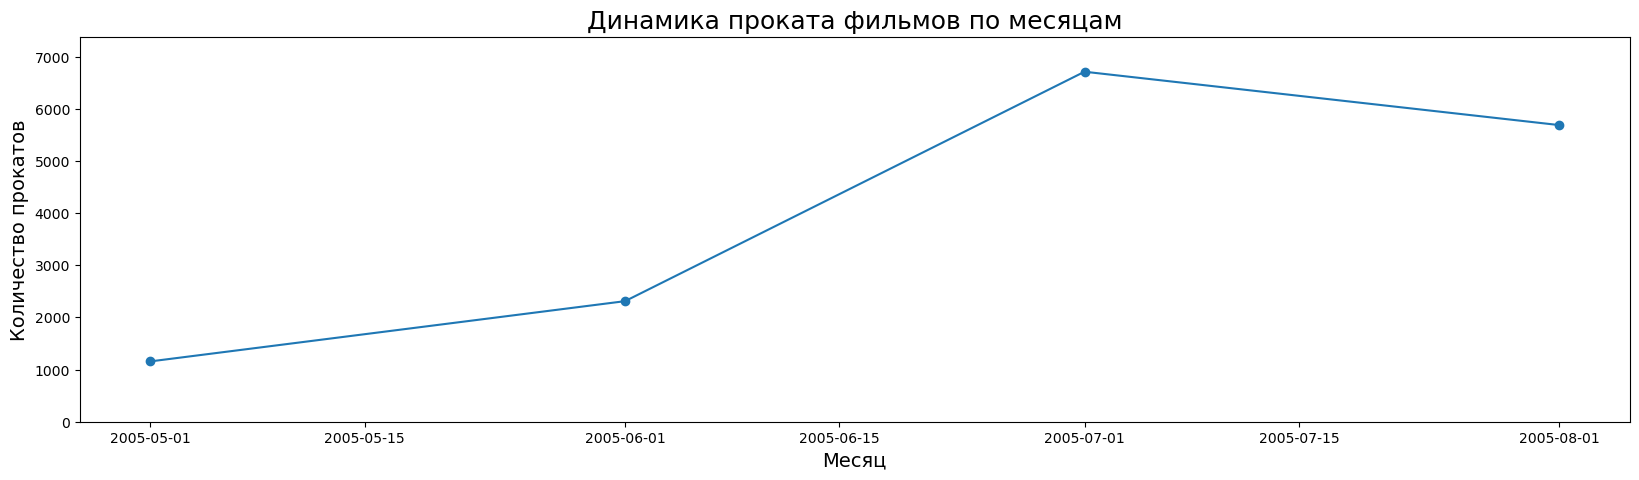

In [15]:
plt.figure(figsize = (20,5))
plt.plot(rental_dynamics["rental_month"], rental_dynamics["rental_cnt"], marker = "o") # marker - указываем как обозначить точки с данными
plt.title("Динамика проката фильмов по месяцам", fontsize = 18)
plt.xlabel("Месяц", fontsize = 14)
plt.ylabel("Количество прокатов", fontsize = 14)
plt.ylim(0, rental_dynamics["rental_cnt"].max()*1.1)
plt.show()

## Рисуем круговую диаграмму с долей оплаченных и неоплаченных прокатов

In [16]:
paid_rentals = (
    data
    .assign(flag_paid = lambda x: x["payment_id"].notna()*1)
    .groupby("flag_paid")
    .agg(rental_cnt = ("rental_id","count"))
    .reset_index()
    .assign(paid_state = lambda x: x["flag_paid"].replace({0: "not paid", 1: "paid"}))
)
paid_rentals

,flag_paid,rental_cnt,paid_state
0,0,1452,not paid
1,1,14596,paid


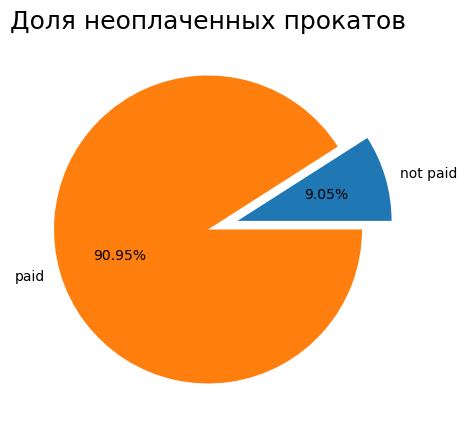

In [17]:
plt.figure(figsize = (20,5))
plt.pie(x = paid_rentals["rental_cnt"], labels = paid_rentals["paid_state"], autopct = "%.2f%%", explode = [0.2, 0])
plt.title("Доля неоплаченных прокатов", fontsize = 18)
plt.show()

# Продвинутые графики в seaborn

## Нарисуем тепловую карту с количеством прокатов по ставке и по длительности проката

In [18]:
heatmap_data = (
    data
    .pivot_table(index = "normative_rental_duration", columns = "rental_rate", values = "rental_id", aggfunc = "nunique")
)

heatmap_data

rental_rate,0.99,2.99,4.99
normative_rental_duration,,,
3 days,1447,947,1018
4 days,1177,979,1095
5 days,902,1001,1262
6 days,1230,1141,1021
7 days,896,1052,876


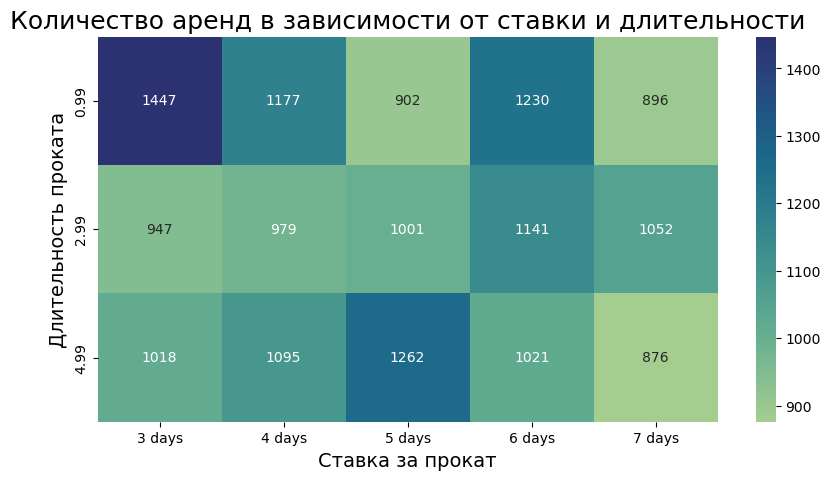

In [20]:
plt.figure(figsize = (10,5))
sns.heatmap(heatmap_data.T, annot = True, fmt = "g", cmap = "crest")
plt.title("Количество аренд в зависимости от ставки и длительности", fontsize = 18)
plt.xlabel("Ставка за прокат", fontsize = 14)
plt.ylabel("Длительность проката", fontsize = 14)
plt.show()

## Как поместить несколько графиков на одно поле

In [22]:
monthly_stats = (
    data
    .assign(rental_month = lambda x: pd.to_datetime(x["rental_date"]).dt.to_period("M").dt.to_timestamp())
    .assign(fact_rental_duration = lambda x: pd.to_timedelta(x["fact_rental_duration"]))
    .groupby("rental_month")
    .agg(
        average_rental_duration = ("fact_rental_duration", "mean"),
        total_payments = ("amount", "sum")
    )
    .assign(average_rental_duration = lambda x: x["average_rental_duration"]/np.timedelta64(1, 'D'))
    .reset_index()
)

monthly_stats

,rental_month,average_rental_duration,total_payments
0,2005-05-01,4.900972,0.00
1,2005-06-01,5.047450,8349.85
2,2005-07-01,5.022756,28377.87
3,2005-08-01,5.047487,24070.14
4,2006-02-01,NaN,514.18


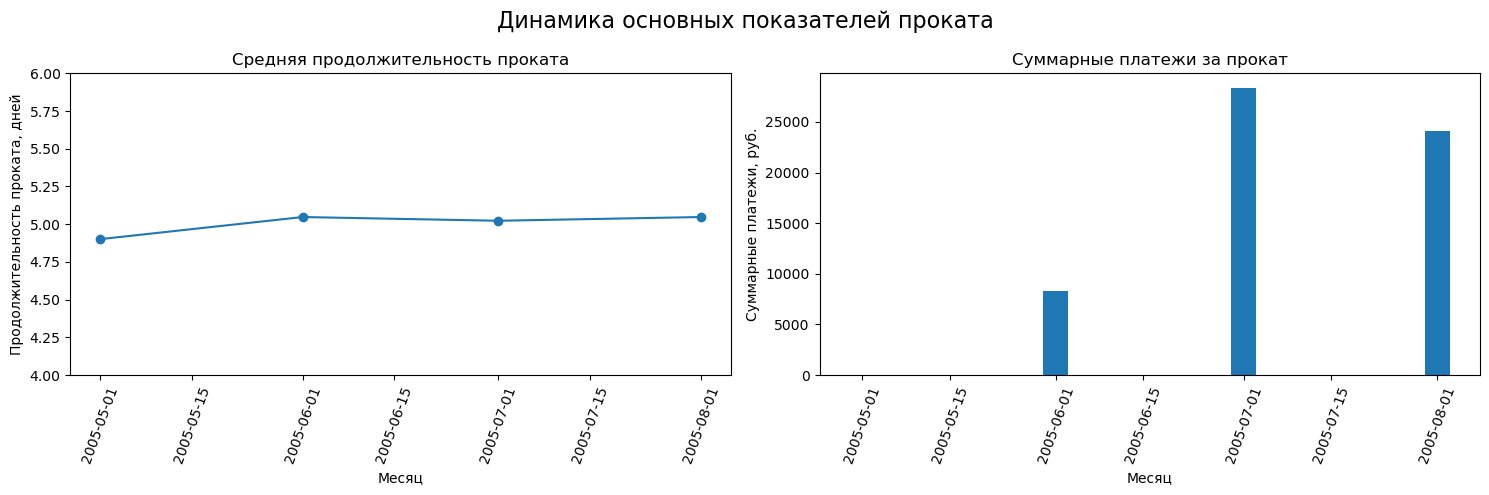

In [24]:
fig, ax = plt.subplots(1, 2, figsize = (15,5)) # Первое число - количество графиков по вертикали (строк), второе число - количество графиков по горизонтали (столбцов)
# ax - это матрица, состоящая из "мест" под графики
plt.suptitle("Динамика основных показателей проката", fontsize = 16)
ax[0].plot(monthly_stats.dropna()["rental_month"], monthly_stats.dropna()["average_rental_duration"], marker = 'o')
ax[0].set_title("Средняя продолжительность проката")
ax[0].set_xlabel("Месяц")
ax[0].set_ylabel("Продолжительность проката, дней")
ax[0].set_ylim(4, 6)
ax[0].tick_params("x", labelrotation = 70)
ax[1].bar(x = monthly_stats.dropna()["rental_month"], height = monthly_stats.dropna()["total_payments"], width = 4)
ax[1].set_title("Суммарные платежи за прокат")
ax[1].set_xlabel("Месяц")
ax[1].set_ylabel("Суммарные платежи, руб.")
ax[1].tick_params("x", labelrotation = 70)
plt.tight_layout() #Указывается, чтобы элементы графиков не наезжали друг на друга
plt.show()

## Гистограмма

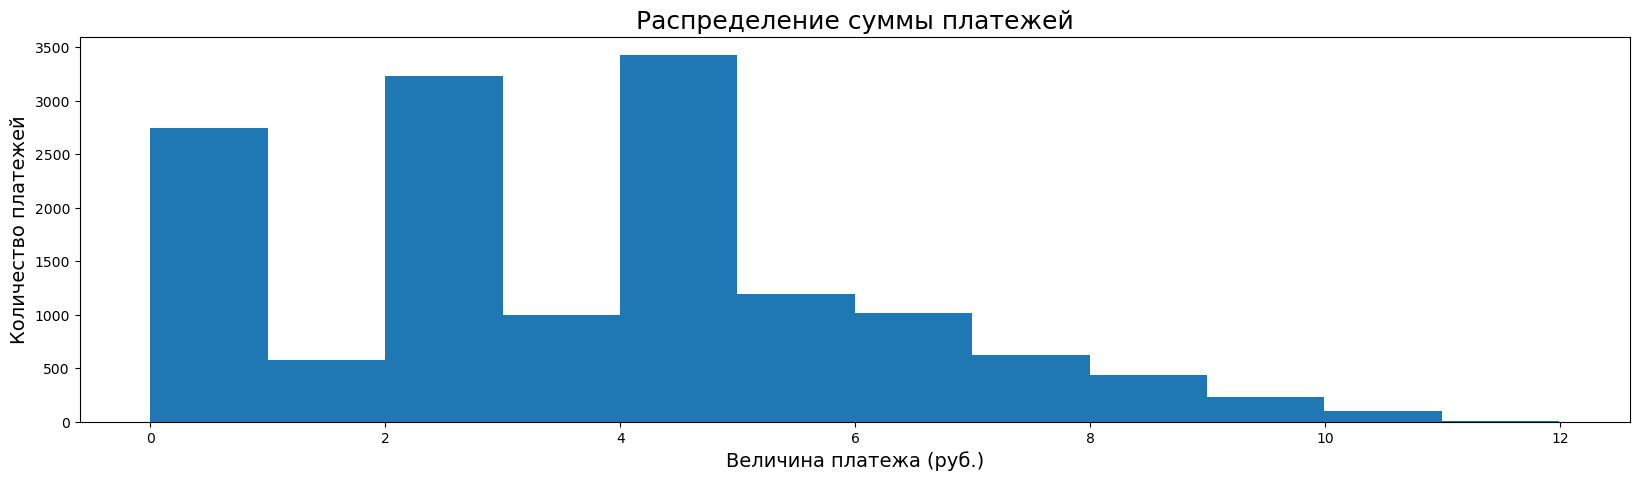

In [27]:
# Построим гистограмму для переменной amount
plt.figure(figsize = (20,5))
plt.hist(data["amount"], bins = 12)
plt.title("Распределение суммы платежей", fontsize = 18)
plt.xlabel("Величина платежа (руб.)", fontsize = 14)
plt.ylabel("Количество платежей", fontsize = 14)
plt.show()

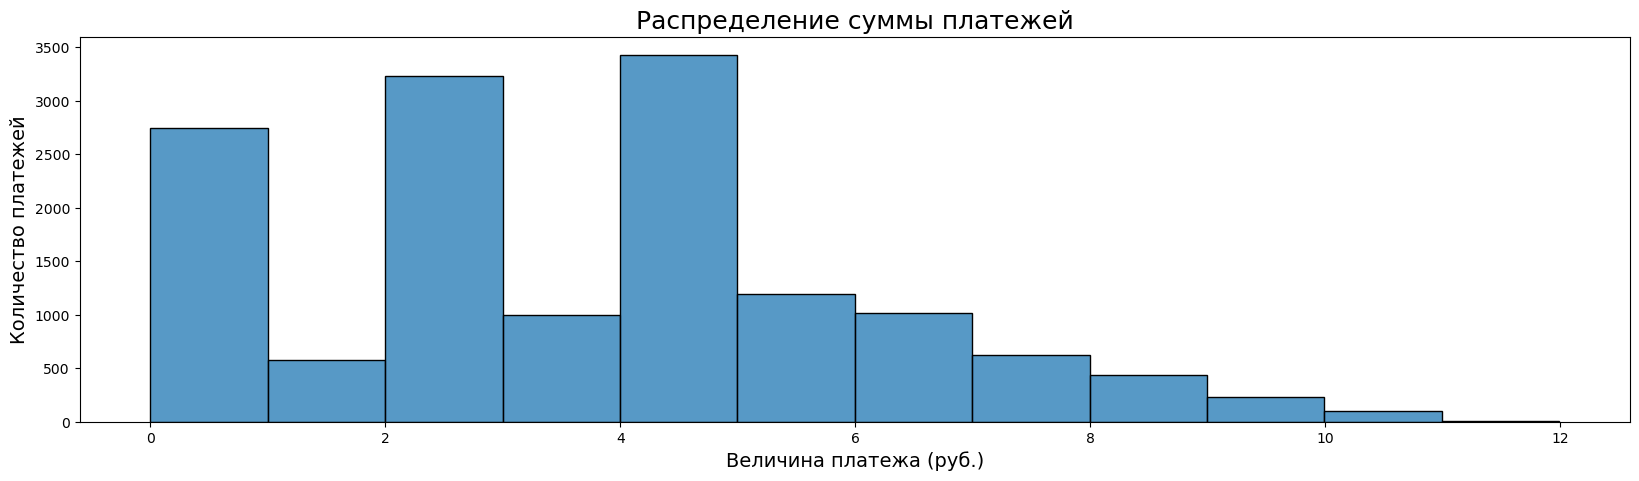

In [29]:
# Построим гистограмму для переменной amount
plt.figure(figsize = (20,5))
sns.histplot(x = "amount", data = data, bins = 12)
plt.title("Распределение суммы платежей", fontsize = 18)
plt.xlabel("Величина платежа (руб.)", fontsize = 14)
plt.ylabel("Количество платежей", fontsize = 14)
plt.show()

## Точечная диаграмма с использованием цвета и размера точки

In [17]:
data.head()

,rental_id,rental_date,return_date,fact_rental_duration,flag_returned,inventory_id,customer_id,staff_id,store_id_x,email,...,customer_name,film_id,store_id_y,normative_rental_duration,film_name,rental_rate,payment_id,amount,payment_date,rental_overdue
16047,1,2005-05-24 22:53:30,2005-05-26 22:04:30,1 days 23:11:00,1,367,130,1,1,charlotte.hunter@sakilacustomer.org,...,Charlotte Hunter,80,1,7 days,Blanket Beverly,2.99,NaN,NaN,NaN,-6 days +23:11:00
0,2,2005-05-24 22:54:33,2005-05-28 19:40:33,3 days 20:46:00,1,1525,459,1,1,tommy.collazo@sakilacustomer.org,...,Tommy Collazo,333,2,7 days,Freaky Pocus,2.99,NaN,NaN,NaN,-4 days +20:46:00
1,3,2005-05-24 23:03:39,2005-06-01 22:12:39,7 days 23:09:00,1,1711,408,1,1,manuel.murrell@sakilacustomer.org,...,Manuel Murrell,373,2,7 days,Graduate Lord,2.99,NaN,NaN,NaN,0 days 23:09:00
2,4,2005-05-24 23:04:41,2005-06-03 01:43:41,9 days 02:39:00,1,2452,333,2,2,andrew.purdy@sakilacustomer.org,...,Andrew Purdy,535,1,6 days,Love Suicides,0.99,NaN,NaN,NaN,3 days 02:39:00
3,5,2005-05-24 23:05:21,2005-06-02 04:33:21,8 days 05:28:00,1,2079,222,1,2,delores.hansen@sakilacustomer.org,...,Delores Hansen,450,2,5 days,Idols Snatchers,2.99,NaN,NaN,NaN,3 days 05:28:00


In [18]:
customer_stats = (
    data
    .assign(rental_date = lambda x: pd.to_datetime(x["rental_date"]))
    .query("rental_date <'2005-12-01'") # Убираем аренды 2006 года
    .assign(flag_overdue = lambda x: ((pd.to_timedelta(x["fact_rental_duration"])-pd.to_timedelta(x["normative_rental_duration"]))>np.timedelta64(6, "D"))*1)
    .groupby("customer_id")
    .agg(
        last_order_date = ("rental_date", "max"),
        frequency = ("rental_id", "nunique"),
        monetary = ("amount", "mean"),
        flag_overdue = ("flag_overdue", "max")

    )
    .assign(recency = lambda x: (x["last_order_date"].max() - x["last_order_date"])/np.timedelta64(1, 'D'))

)

customer_stats.head()

,last_order_date,frequency,monetary,flag_overdue,recency
customer_id,,,,,
1,2005-08-22 20:03:46,32,3.823333,1,1.115579
2,2005-08-23 17:39:35,27,4.759231,1,0.215706
3,2005-08-23 07:10:14,26,5.448333,0,0.652755
4,2005-08-23 07:43:00,22,3.717273,0,0.630000
5,2005-08-22 17:37:02,37,3.931176,0,1.217477


In [19]:
customer_stats["monetary"].describe()

count    599.000000
mean       4.213424
std        0.497154
min        2.779474
25%        3.884737
50%        4.204286
75%        4.583171
max        5.619630
Name: monetary, dtype: float64

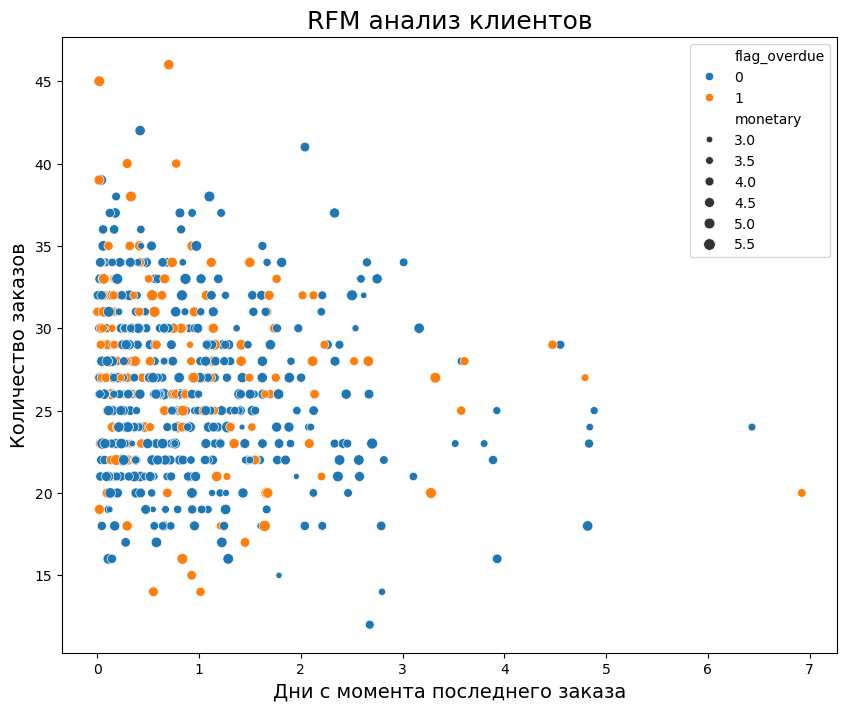

In [20]:
# Построим точечную диаграмму
plt.figure(figsize = (10,8))
sns.scatterplot(x = "recency", y = "frequency", size = "monetary", hue = "flag_overdue", data = customer_stats)
# size - какая переменная будет отвечать за размер кругляшка
# hue - какая переменная отвечает за цвет кругляшка
plt.title("RFM анализ клиентов", fontsize = 18)
plt.xlabel("Дни с момента последнего заказа", fontsize = 14)
plt.ylabel("Количество заказов", fontsize = 14)
plt.show()